In [ ]:
# need to implement test GW algorithm on S2s first.
# the algorithm 1 should work theoretically (and it should work better with correctly computed distances, so well approximated geodesics)
# compute on the S2s first as here we have the correct geodesics.


# I want to get the P coupling matrix (screenshot and validate)
# this should not be uniform, neither with just 0s and 1, but it should have a clear structure (it is still entropic solving GW, so all entries should be > 0, but there should be one higher value)


In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import matplotlib.pyplot as plt
import torch
import pandas as pd
import ot


from sklearn.decomposition import PCA
from scipy.optimize import minimize
from scipy.stats import vonmises_fisher
from scipy.spatial.distance import cdist, pdist, squareform
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


from colors import color_segment
from supervised_vae import SupervisedVAE
from train_two_vaes import train_two_vaes
from plot_vaes import plot_vae_latent_alignment
from geodesics import *

blue_pink = color_segment()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def get_rotation_matrix(theta):
    """
    Generates a 3x3 rotation matrix using the matrix exponential of a skew-symmetric matrix.
    Inputs: theta (array of 3 angles)
    Outputs: R (3x3 rotation matrix)
    """
    tx, ty, tz = theta
    # Skew-symmetric matrix representation of the rotation vector
    A = np.array([[0, -tz, ty],
                  [tz, 0, -tx],
                  [-ty, tx, 0]])
    return scipy.linalg.expm(A)

def sphere_geodesics(points):
    """
    Computes the geodesic distances between points on S2
    Inputs: points (Nx3 array of points)
    Outputs: D (NxN array of geodesic distances)
    """
    inner_product = np.inner(points, points)
    return np.arccos(np.clip(inner_product, -1.0, 1.0))

def sample_vmf_on_sphere(mu, kappa, n_samples):
    """
    Sample from a Von Mises-Fisher distribution on the unit sphere.
    Ensures the mean direction is normalized and uses scipy to sample 
           directly on the S2 manifold where ||z|| = 1.
    Inputs: mu (mean direction), kappa (concentration), n_samples (int)
    Outputs: points (n_samples x 3) where ||z|| = 1
    """
    # Ensure the mean direction is a unit vector
    mu_normalized = mu / np.linalg.norm(mu)
    
    # Sample directly from the VMF distribution on the sphere
    points = vonmises_fisher.rvs(mu_normalized, kappa, size=n_samples)
    
    return points

def gromov_wasserstein_loss(D1, D2, P):
    """
    Objective: Calculate the GW objective discrepancy between two intra-distance matrices.
    Logic: Uses an efficient matrix expansion of the quadratic objective:
           Loss = sum_{i,j,i',j'} |D1_ii' - D2_jj'|^2 * P_ij * P_i'j'
           Expanded: C1 + C2 - 2 * (D1 @ P @ D2).
    Inputs: Distance matrices D1 (N x N), D2 (M x M), P (N x M coupling matrix)
    Outputs: gw_loss (float)
    """
    # Extract marginals from the coupling matrix P
    # a: mass distribution on the source manifold
    # b: mass distribution on the target manifold
    a = np.sum(P, axis=1)
    b = np.sum(P, axis=0)

    # Compute constant terms relative to the distance matrices and marginals
    # These represent the 'self-similarities' of each space
    C1 = np.dot(np.dot(D1**2, a[:, np.newaxis]), np.ones((1, len(b))))
    C2 = np.dot(np.ones((len(a), 1)), np.dot(b[np.newaxis, :], (D2**2).T))

    # Compute the cross-term (linearized gradient term)
    # This captures how the pairwise distances align across the manifolds
    cross_term = 2 * np.dot(D1, np.dot(P, D2))

    # The full cost matrix for the current coupling P
    cost_matrix = C1 + C2 - cross_term

    # Final discrepancy is the sum of cost weighted by the transport plan
    return np.sum(cost_matrix * P)

def solve_sinkhorn_coupling(cost_matrix, epsilon, a, b, pairs=None, n_iters=200):
    """
    Objective: Solve for the optimal coupling matrix P using Sinkhorn iterations.
    Logic: Implements entropic OT in a numerically stabilized form. In paired experiments,
           modifies the cost matrix to lock anchor mass between specific indices.
    Inputs: cost_matrix (N x M), epsilon (reg parameter), a/b (marginals),
            pairs (list of tuples, optional), n_iters (int)
    Outputs: P (optimal coupling matrix)
    """
    # Work on a float copy of the cost matrix to ensure integrity
    C = np.array(cost_matrix, dtype=np.float64, copy=True)

    # If pairs are provided, bias the cost matrix
    # This acts as a hard constraint for the anchor point
    if pairs is not None:
        large_penalty = 1e2
        for i, j in pairs:
            # Penalize all other matches for these rows and columns
            C[i, :] = large_penalty
            C[:, j] = large_penalty
            # Set zero cost for the ground-truth correspondence
            C[i, j] = 0.0

    # Shift the costs so the minimum is zero
    # This keeps the exponentials in a safer numerical range
    C = C - C.min()

    # Compute the stabilized Gibbs kernel
    # Clipping prevents overflow/underflow in exp
    scaled_cost = -C / epsilon
    scaled_cost = np.clip(scaled_cost, -700, 50)
    K = np.exp(scaled_cost)

    # Avoid exact zeros in the kernel
    # This prevents divisions by zero in the Sinkhorn updates
    K = np.maximum(K, 1e-300)

    # Initialize scaling vectors
    n, m = C.shape
    u = np.ones(n) / n
    v = np.ones(m) / m

    # Perform Sinkhorn iterations to satisfy marginal constraints
    # These iterations consist of simple matrix-vector products
    for _ in range(n_iters):
        # Update v (target scaling)
        KTu = K.T @ u
        KTu = np.maximum(KTu, 1e-300)
        v = b / KTu

        # Update u (source scaling)
        Kv = K @ v
        Kv = np.maximum(Kv, 1e-300)
        u = a / Kv

    # Reconstruct the optimal coupling matrix P = diag(u) K diag(v)
    P = u[:, np.newaxis] * K * v[np.newaxis, :]

    # Normalize once at the end to reduce accumulated numerical drift
    P = P / (P.sum() + 1e-16)

    return P

def solve_gw_coupling(D1, D2, epsilon=0.1, threshold=1e-6, max_iter=200):
    D1 = np.array(D1, dtype=np.float64, copy=True)
    D2 = np.array(D2, dtype=np.float64, copy=True)

    D1 = D1 / (D1.max() + 1e-12)
    D2 = D2 / (D2.max() + 1e-12)

    n = D1.shape[0]
    m = D2.shape[0]

    a = np.ones(n) / n
    b = np.ones(m) / m

    P = a[:, None] @ b[None, :]
    gw_old = np.inf

    for _ in range(max_iter):
        cost_gradient = -D1 @ P @ D2
        P = solve_sinkhorn_coupling(cost_gradient, epsilon, a, b)

        gw_new = gromov_wasserstein_loss(D1, D2, P)

        if abs(gw_new - gw_old) < threshold:
            break

        gw_old = gw_new

    return P, gw_new

>> be very sure about the hyperparameters for the GW solver!

In [4]:
theta_true = np.array([0.5, 0.3, 0.2])
R_true = get_rotation_matrix(theta_true)

Phase 4 epoch    1 | loss = 0.691273
Phase 4 epoch  200 | loss = 0.245777
Phase 4 epoch  400 | loss = 0.120280
Phase 4 epoch  600 | loss = 0.078967
Phase 4 epoch  800 | loss = 0.067301
Phase 4 epoch 1000 | loss = 0.062943
Phase 4 epoch 1200 | loss = 0.059940

Diagnostics
-----------
Entropy(P*): 8.367558065247552
Mass on same-component blocks: 0.9744591599843991
Per-block masses: {0: np.float64(0.5132675413528751), 1: np.float64(0.2833333333333334), 2: np.float64(0.17785828529819062)}
Estimated rotation parameters: [ 0.49024835 -0.30770773  0.52509034]
True rotation parameters: [ 0.8 -0.4  0.5]
Rotation error wrt true theta (radians): 0.3195986746245569


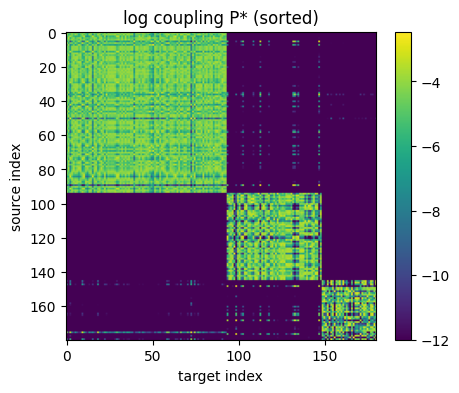

In [22]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.stats import vonmises_fisher
import torch
import torch.nn as nn
import torch.optim as optim
import ot

# ============================================================
# Geometry on S2
# ============================================================
def normalize_rows_np(X):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

def sphere_geodesics_np(X):
    X = normalize_rows_np(X)
    G = np.clip(X @ X.T, -1.0 + 1e-12, 1.0 - 1e-12)
    return np.arccos(G)

def sphere_geodesic_pointwise_np(X, Y):
    X = normalize_rows_np(X)
    Y = normalize_rows_np(Y)
    G = np.clip(X @ Y.T, -1.0 + 1e-12, 1.0 - 1e-12)
    return np.arccos(G)

def normalize_rows_torch(X):
    return X / (torch.norm(X, dim=1, keepdim=True) + 1e-12)

def sphere_geodesic_pointwise_torch(X, Y, eps=1e-6):
    X = normalize_rows_torch(X)
    Y = normalize_rows_torch(Y)
    G = X @ Y.T
    G = torch.clamp(G, -1.0 + eps, 1.0 - eps)
    return torch.arccos(G)

# ============================================================
# Rotation matrix
# ============================================================
def get_rotation_matrix_np(theta):
    tx, ty, tz = theta
    A = np.array([[0, -tz, ty],
                  [tz, 0, -tx],
                  [-ty, tx, 0]], dtype=float)
    return scipy.linalg.expm(A)

# ============================================================
# Sampling
# ============================================================
def sample_uniform_s2(n):
    X = np.random.randn(n, 3)
    return normalize_rows_np(X)

def sample_vmf_on_sphere(mu, kappa, n):
    mu = np.asarray(mu, dtype=float)
    mu = mu / (np.linalg.norm(mu) + 1e-12)
    return vonmises_fisher.rvs(mu, kappa, size=n)

def sample_vmf_mixture(mus, kappas, weights, n):
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    comp_ids = np.random.choice(len(weights), size=n, p=weights)

    X = []
    labels = []
    for c in comp_ids:
        x = sample_vmf_on_sphere(mus[c], kappas[c], 1)
        X.append(np.asarray(x).reshape(1, 3))
        labels.append(c)
    return np.vstack(X), np.array(labels)

# ============================================================
# Phase 2: Entropic Gromov-Wasserstein
# ============================================================
def solve_entropic_gw(Ca, Cb, epsilon=0.02):
    n = Ca.shape[0]
    m = Cb.shape[0]
    p = np.ones(n) / n
    q = np.ones(m) / m
    P0 = np.outer(p, q)

    P_star = ot.gromov.entropic_gromov_wasserstein(
        C1=Ca,
        C2=Cb,
        p=p,
        q=q,
        loss_fun="square_loss",
        epsilon=epsilon,
        G0=P0
    )
    return P_star

# ============================================================
# Phase 3: Map parameterization
# ============================================================
class SphereResidualFlow(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(3))

        self.residual = nn.Sequential(
            nn.Linear(3, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 3)
        )

        for m in self.residual.modules():
            if isinstance(m, nn.Linear):
                nn.init.zeros_(m.weight)
                nn.init.zeros_(m.bias)

    def rotation_matrix(self):
        tx, ty, tz = self.theta[0], self.theta[1], self.theta[2]
        zero = torch.zeros((), device=tx.device, dtype=tx.dtype)
        A = torch.stack([
            torch.stack([zero, -tz,   ty]),
            torch.stack([tz,   zero, -tx]),
            torch.stack([-ty,  tx,   zero])
        ])
        return torch.matrix_exp(A)

    def forward(self, x):
        R = self.rotation_matrix()
        x_rot = x @ R.T
        x_out = x_rot + self.residual(x)
        x_out = normalize_rows_torch(x_out)
        return x_out

# ============================================================
# Phase 4: Monge refinement
# ============================================================
def refine_map_phase4(X_src, X_tgt, P_star, n_epochs=1200, lr=1e-3, use_geodesic_loss=True, verbose=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    Xs = torch.tensor(X_src, dtype=torch.float32, device=device)
    Xt = torch.tensor(X_tgt, dtype=torch.float32, device=device)
    P  = torch.tensor(P_star, dtype=torch.float32, device=device)

    model = SphereResidualFlow(hidden=64).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = []

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        Xs_map = model(Xs)

        if use_geodesic_loss:
            D = sphere_geodesic_pointwise_torch(Xs_map, Xt, eps=1e-6)
            loss = torch.sum(P * (D ** 2))
        else:
            diff2 = torch.sum((Xs_map[:, None, :] - Xt[None, :, :]) ** 2, dim=2)
            loss = torch.sum(P * diff2)

        if not torch.isfinite(loss):
            print(f"Non-finite loss at epoch {epoch+1}")
            break

        loss.backward()

        # gradient clipping helps a lot here
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)

        optimizer.step()

        history.append(loss.item())

        if verbose and (epoch == 0 or (epoch + 1) % 200 == 0):
            print(f"Phase 4 epoch {epoch+1:4d} | loss = {loss.item():.6f}")

    with torch.no_grad():
        Xs_map = model(Xs).cpu().numpy()
        theta_hat = model.theta.detach().cpu().numpy()

    return model, Xs_map, theta_hat, history

# ============================================================
# Full Algorithm 1 without LDD
# ============================================================
def algorithm1_without_ldd_on_spheres(X_src, X_tgt, epsilon_gw=0.02, n_epochs=1200, lr=1e-3, use_geodesic_loss=True, verbose=True):
    Ca = sphere_geodesics_np(X_src)
    Cb = sphere_geodesics_np(X_tgt)
    P_star = solve_entropic_gw(Ca, Cb, epsilon=epsilon_gw)

    model, X_src_mapped, theta_hat, history = refine_map_phase4(
        X_src, X_tgt, P_star,
        n_epochs=n_epochs,
        lr=lr,
        use_geodesic_loss=use_geodesic_loss,
        verbose=verbose
    )

    return {
        "Ca": Ca,
        "Cb": Cb,
        "P_star": P_star,
        "model": model,
        "X_src_mapped": X_src_mapped,
        "theta_hat": theta_hat,
        "history": history
    }

# ============================================================
# Diagnostics
# ============================================================
def coupling_entropy(P):
    P_safe = np.clip(P, 1e-15, None)
    return -np.sum(P_safe * np.log(P_safe))

def mass_on_same_component_blocks(P, y_src, y_tgt):
    total = 0.0
    per_block = {}
    for k in np.unique(y_src):
        rows = np.where(y_src == k)[0]
        cols = np.where(y_tgt == k)[0]
        block_mass = P[np.ix_(rows, cols)].sum()
        total += block_mass
        per_block[int(k)] = block_mass
    return total, per_block

def rotation_matrix_error_from_theta(theta_hat, theta_true):
    R_hat = get_rotation_matrix_np(theta_hat)
    R_true = get_rotation_matrix_np(theta_true)
    R = R_hat.T @ R_true
    val = np.clip((np.trace(R) - 1.0) / 2.0, -1.0, 1.0)
    return np.arccos(val)

# ============================================================
# Example run
# ============================================================
np.random.seed(7)
torch.manual_seed(7)

n = 180
theta_true = np.array([0.8, -0.4, 0.5])
R_true = get_rotation_matrix_np(theta_true)

mus_src = [
    normalize_rows_np(np.array([[0.0, 0.0, 1.0]])).ravel(),
    normalize_rows_np(np.array([[1.0, 0.3, 0.1]])).ravel(),
    normalize_rows_np(np.array([[-0.5, 0.7, 0.4]])).ravel(),
]
kappas = [45, 25, 18]
weights = [0.50, 0.30, 0.20]
mus_tgt = [R_true @ mu for mu in mus_src]

X_src, y_src = sample_vmf_mixture(mus_src, kappas, weights, n)
X_tgt, y_tgt = sample_vmf_mixture(mus_tgt, kappas, weights, n)

out = algorithm1_without_ldd_on_spheres(
    X_src, X_tgt,
    epsilon_gw=0.02,
    n_epochs=1200,
    lr=1e-3,
    use_geodesic_loss=True,
    verbose=True
)

P_star = out["P_star"]
theta_hat = out["theta_hat"]

print("\nDiagnostics")
print("-----------")
print("Entropy(P*):", coupling_entropy(P_star))
total_block_mass, per_block = mass_on_same_component_blocks(P_star, y_src, y_tgt)
print("Mass on same-component blocks:", total_block_mass)
print("Per-block masses:", per_block)
print("Estimated rotation parameters:", theta_hat)
print("True rotation parameters:", theta_true)
print("Rotation error wrt true theta (radians):", rotation_matrix_error_from_theta(theta_hat, theta_true))

idx_src = np.argsort(y_src)
idx_tgt = np.argsort(y_tgt)
P_sorted = P_star[np.ix_(idx_src, idx_tgt)]

plt.figure(figsize=(5,4))
plt.imshow(np.log10(P_sorted + 1e-12), aspect='auto')
plt.colorbar()
plt.title("log coupling P* (sorted)")
plt.xlabel("target index")
plt.ylabel("source index")
plt.show()

^^ “For the sphere mixture experiment, the target data were generated by rotating the parameters of the source mixture distribution and then drawing an independent sample from the resulting rotated law. Thus, the setup is unpaired at the sample level, while still preserving a known ground-truth global transformation at the distribution level.”

Text(0.5, 1.0, 'P (log)')

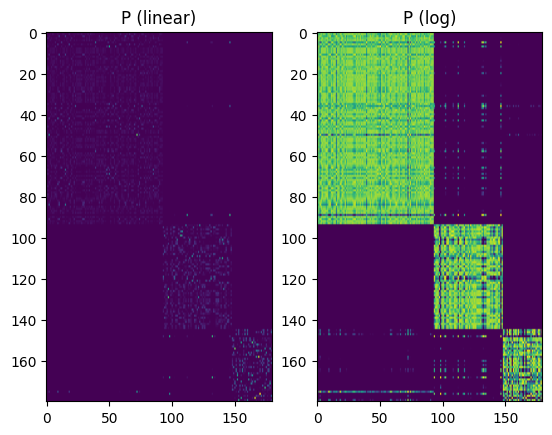

In [23]:
plt.subplot(1,2,1)
plt.imshow(P_sorted, aspect='auto')
plt.title("P (linear)")

plt.subplot(1,2,2)
plt.imshow(np.log10(P_sorted + 1e-12), aspect='auto')
plt.title("P (log)")

Phase 4 epoch    1 | loss = 4.176214
Phase 4 epoch  200 | loss = 3.556557
Phase 4 epoch  400 | loss = 2.981808
Phase 4 epoch  600 | loss = 2.651165
Phase 4 epoch  800 | loss = 2.477828
Phase 4 epoch 1000 | loss = 2.317477
Phase 4 epoch 1200 | loss = 2.115678

Diagnostics
-----------
Entropy(P*): 6.552849542346991
Min entry: 1.829418134683051e-105
Max entry: 0.005446037071142774
Uniform entry would be: 3.08641975308642e-05
Estimated rotation parameters: [-0.65697443 -1.0004872  -0.52272016]


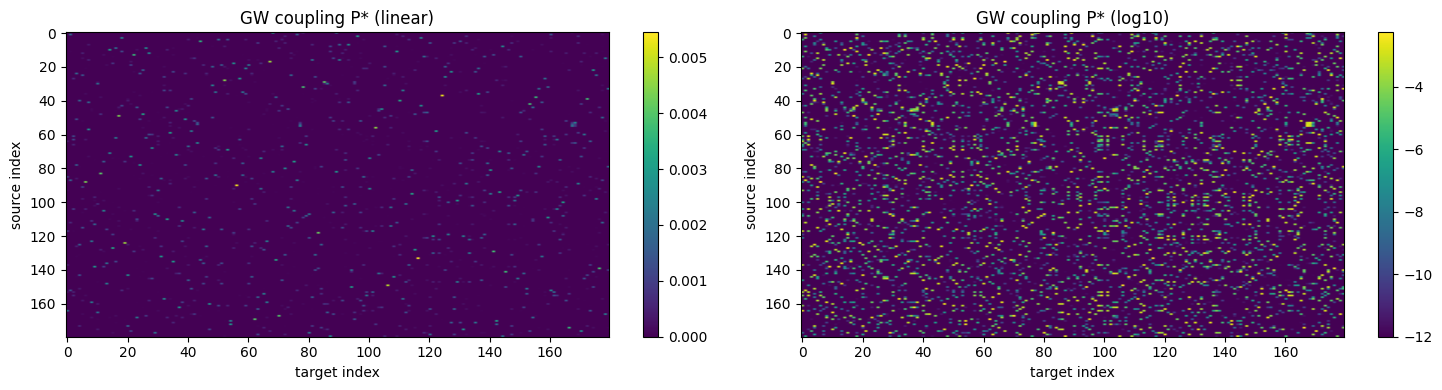

In [25]:
## uniform case on S2

np.random.seed(7)
torch.manual_seed(7)

n = 180

# Unpaired uniform sampling (sample twice independently)
X_src = sample_uniform_s2(n)
X_tgt = sample_uniform_s2(n)

out = algorithm1_without_ldd_on_spheres(
    X_src, X_tgt,
    epsilon_gw=0.02,
    n_epochs=1200,
    lr=1e-3,
    use_geodesic_loss=True,
    verbose=True
)

P_star = out["P_star"]
theta_hat = out["theta_hat"]
history = out["history"]

print("\nDiagnostics")
print("-----------")
print("Entropy(P*):", coupling_entropy(P_star))
print("Min entry:", P_star.min())
print("Max entry:", P_star.max())
print("Uniform entry would be:", 1.0 / (n * n))
print("Estimated rotation parameters:", theta_hat)

plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
plt.imshow(P_star, aspect='auto')
plt.colorbar()
plt.title("GW coupling P* (linear)")
plt.xlabel("target index")
plt.ylabel("source index")

plt.subplot(1,2,2)
plt.imshow(np.log10(P_star + 1e-12), aspect='auto')
plt.colorbar()
plt.title("GW coupling P* (log10)")
plt.xlabel("target index")
plt.ylabel("source index")


plt.tight_layout()
plt.show()

In [ ]:
# DRAFT for initializing using LDD !!

# phase 1. LLD init
def initialize_pi_with_ldd(H_a, H_b, sinkhorn_reg=0.1):
    """
    H_a: Tensor of source LDD signatures [n, B]
    H_b: Tensor of target LDD signatures [n, B]
    sinkhorn_reg: Entropy regularization for the initialization OT
    """
    n = H_a.shape[0]
    
    # 1. Compute pairwise L2 distances between signatures
    # M shape: [n, n]
    M = torch.cdist(H_a, H_b, p=2)**2 
    
    # Normalize M to prevent numerical instability in Sinkhorn
    M = M / M.max()
    
    # 2. Define uniform marginals (1/n for each point)
    a, b = torch.ones(n) / n, torch.ones(n) / n
    
    # 3. Solve Linear OT via Sinkhorn to get the initial coupling
    # We detach and move to CPU/NumPy if using POT, or use PyTorch backend
    pi_0 = ot.sinkhorn(a, b, M, reg=sinkhorn_reg)
    
    return pi_0

# ==========================================
# How to use it in the main pipeline:
# ==========================================

# Step 1: Get signatures and initialize
pi_0 = initialize_pi_with_ldd(H_a, H_b)

# Step 2: Pass pi_0 as the starting point for Entropic GW
# (Assuming C_a and C_b are your intra-space distance matrices)
pi_star = ot.gromov.entropic_gromov_wasserstein(
    C1=D_a, 
    C2=D_b, 
    p=a, 
    q=b, 
    loss_fun='square_loss', 
    epsilon=0.05, # GW entropy regularization
    G0=pi_0       # <--- THIS IS THE WARM START!
)

In [ ]:
# 1. sample from vMF on the S2 (most constrained experiment)


In [ ]:

source_mu = np.array([0., 0., 1.])
kappa = 10
n = 100

data_src = sample_vmf_on_sphere(source_mu, kappa, n)
target_mu = R_true @ source_mu
data_tgt = sample_vmf_on_sphere(target_mu, kappa, n)

D_src = sphere_geodesics(data_src)
D_tgt = sphere_geodesics(data_tgt)

P_star, gw_loss = solve_gw_coupling(D_src, D_tgt, epsilon=0.05)

P_pot = ot.gromov.entropic_gromov_wasserstein(
    C1=D_src,
    C2=D_tgt,
    loss_fun='square_loss',
    epsilon=0.05,
    G0=P_star
)

In [9]:
P_pot

array([[1.52095495e-04, 2.86265667e-05, 1.55232926e-06, ...,
        1.45785356e-06, 1.24657526e-04, 2.49028095e-08],
       [4.69257212e-05, 2.64259398e-05, 8.09363393e-06, ...,
        7.57300018e-06, 2.62238579e-04, 1.48276722e-07],
       [3.10846132e-04, 1.24786479e-05, 9.59452994e-08, ...,
        6.92179996e-08, 3.10325573e-06, 2.09720855e-08],
       ...,
       [5.60009171e-08, 1.25393693e-05, 6.91746682e-04, ...,
        7.01998496e-04, 1.33760942e-05, 1.12589291e-03],
       [5.18508661e-07, 1.91431424e-05, 6.23510307e-04, ...,
        6.03580269e-04, 1.47104094e-04, 1.32952553e-04],
       [4.43333243e-06, 1.94557232e-04, 8.53995301e-06, ...,
        1.04237981e-05, 1.41521362e-06, 1.77260915e-05]], shape=(100, 100))

In [ ]:
# 2. sample uniform on the S2

# should sample uniform on source S2 and again sample 

In [ ]:
# 3. mixture of vMFs